In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import data 
data = pd.read_csv("3) Sentiment dataset.csv", encoding='unicode_escape')

In [4]:
data.shape

(732, 15)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [6]:
data.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! ðª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [7]:
data["Timestamp"] = pd.to_datetime(data["Timestamp"])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Unnamed: 0.1  732 non-null    int64         
 1   Unnamed: 0    732 non-null    int64         
 2   Text          732 non-null    object        
 3   Sentiment     732 non-null    object        
 4   Timestamp     732 non-null    datetime64[ns]
 5   User          732 non-null    object        
 6   Platform      732 non-null    object        
 7   Hashtags      732 non-null    object        
 8   Retweets      732 non-null    float64       
 9   Likes         732 non-null    float64       
 10  Country       732 non-null    object        
 11  Year          732 non-null    int64         
 12  Month         732 non-null    int64         
 13  Day           732 non-null    int64         
 14  Hour          732 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(

In [10]:
data.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [11]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [12]:
data.describe()

,Unnamed: 0.1,Unnamed: 0,Timestamp,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,2020-12-08 21:37:38.196721408,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
min,0.000000,0.000000,2010-05-15 15:30:00,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,2019-03-08 17:27:30,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,2021-09-20 14:30:00,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,2023-02-26 11:48:45,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,2023-10-22 20:45:00,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000
std,211.513936,212.428936,NaN,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414


In [13]:
data.median(numeric_only=True)

Unnamed: 0.1     366.5
Unnamed: 0       370.5
Retweets          22.0
Likes             43.0
Year            2021.0
Month              6.0
Day               15.0
Hour              16.0
dtype: float64

In [14]:
data.mode(numeric_only=True)

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
0,0,0,22.0,45.0,2023.0,2.0,15.0,14.0
1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3,NaN,NaN,NaN,NaN,NaN,NaN
4,4,4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
727,728,732,NaN,NaN,NaN,NaN,NaN,NaN
728,729,733,NaN,NaN,NaN,NaN,NaN,NaN
729,730,734,NaN,NaN,NaN,NaN,NaN,NaN
730,731,735,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
data.std(numeric_only=True)

Unnamed: 0.1    211.513936
Unnamed: 0      212.428936
Retweets          7.061286
Likes            14.089848
Year              2.802285
Month             3.411763
Day               8.474553
Hour              4.113414
dtype: float64

In [16]:
data.describe()

,Unnamed: 0.1,Unnamed: 0,Timestamp,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,2020-12-08 21:37:38.196721408,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
min,0.000000,0.000000,2010-05-15 15:30:00,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,2019-03-08 17:27:30,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,2021-09-20 14:30:00,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,2023-02-26 11:48:45,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,2023-10-22 20:45:00,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000
std,211.513936,212.428936,NaN,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414


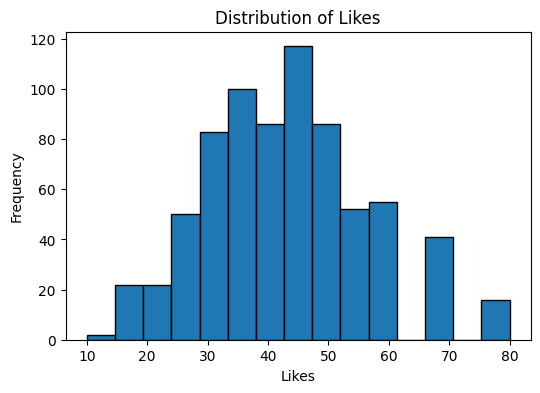

In [18]:
plt.figure(figsize=(6,4))
plt.hist(data['Likes'], bins=15, edgecolor='black')
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()

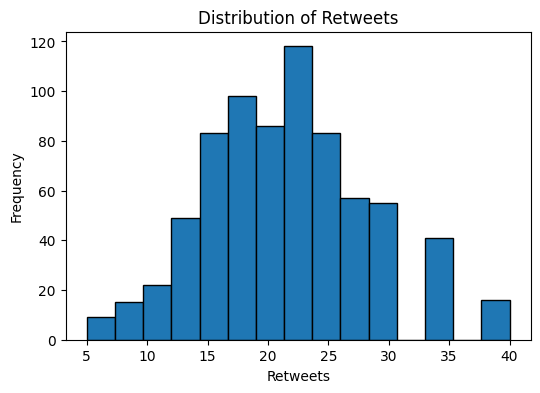

In [19]:
plt.figure(figsize=(6,4))
plt.hist(data['Retweets'], bins=15, edgecolor='black')
plt.title("Distribution of Retweets")
plt.xlabel("Retweets")
plt.ylabel("Frequency")
plt.show()

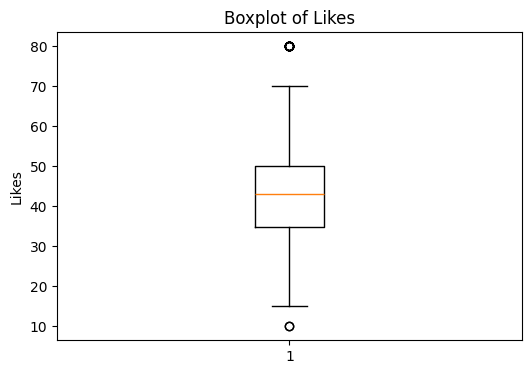

In [20]:
plt.figure(figsize=(6,4))
plt.boxplot(data['Likes'])
plt.title("Boxplot of Likes")
plt.ylabel("Likes")
plt.show()

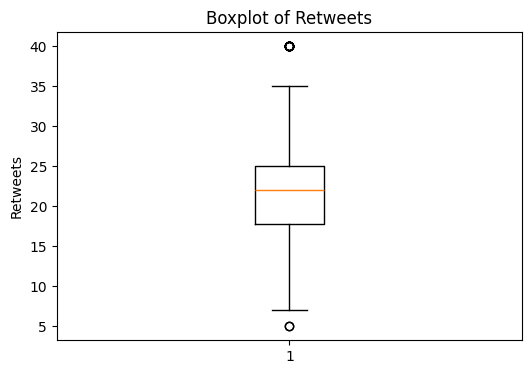

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot(data['Retweets'])
plt.title("Boxplot of Retweets")
plt.ylabel("Retweets")
plt.show()

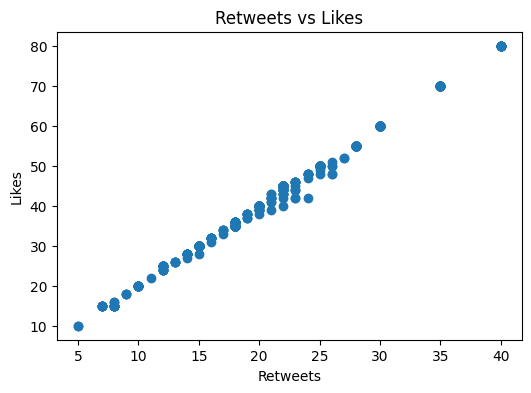

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(data['Retweets'], data['Likes'])
plt.title("Retweets vs Likes")
plt.xlabel("Retweets")
plt.ylabel("Likes")
plt.show()

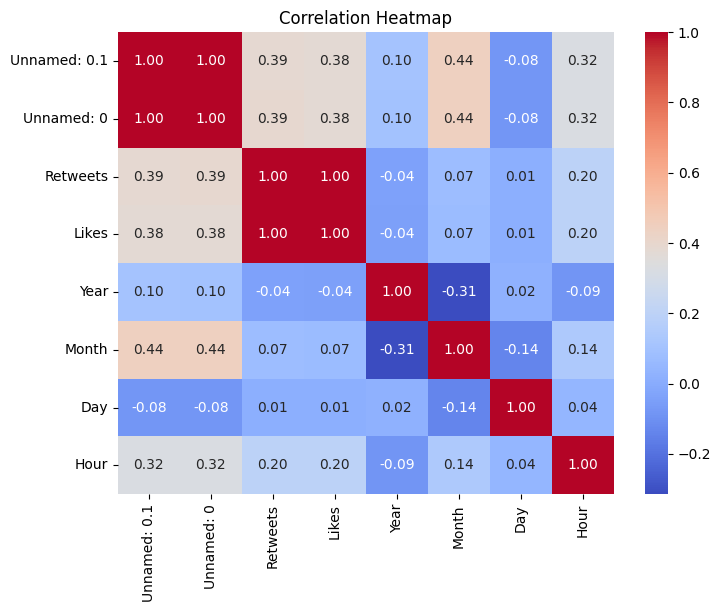

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
corr = data.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()